In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'D:\ME\Machine learning\Projects\Social media impact on students\Data\Social_media_impact_on_life.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   object 
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   object 
 3   Academic_Level               4500 non-null   object 
 4   Primary_Platform             4500 non-null   object 
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   object 
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   object 
 12  Perceived_Stress_Score       4454 non-null   float64
 13  Mental_Health_Inde

In [5]:
df.drop(['Student_ID'], axis=1, inplace=True)

In [6]:
df.isna().sum()

Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score         46
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
dtype: int64

In [7]:
df['Perceived_Stress_Score']

0       20.0
1       17.0
2       18.0
3       15.0
4       16.0
        ... 
4495    11.0
4496     9.0
4497    13.0
4498    22.0
4499    10.0
Name: Perceived_Stress_Score, Length: 4500, dtype: float64

In [8]:
df['Perceived_Stress_Score'].describe()

count    4454.000000
mean       13.512124
std         7.072859
min         0.000000
25%         9.000000
50%        13.000000
75%        18.000000
max        40.000000
Name: Perceived_Stress_Score, dtype: float64

In [9]:
df['Perceived_Stress_Score'].fillna(df['Perceived_Stress_Score'].mean(), inplace=True)

In [10]:
df['Academic_Performance_GPA'].describe()

count    4415.000000
mean        3.429282
std         0.392662
min         1.900000
25%         3.200000
50%         3.460000
75%         3.720000
max         4.000000
Name: Academic_Performance_GPA, dtype: float64

In [11]:
df['Academic_Performance_GPA'].fillna(df['Academic_Performance_GPA'].mean(), inplace=True)

C:\Users\Mahmoud shaban\AppData\Local\Temp\ipykernel_34980\3008632643.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Academic_Performance_GPA'].fillna(df['Academic_Performance_GPA'].mean(), inplace=True)


In [12]:
df.isna().sum()

Age                            0
Gender                         0
Academic_Level                 0
Primary_Platform               0
Daily_Usage_Hours              0
Weekend_Extra_Hours            0
Device_Type                    0
Sleep_Duration_Hours           0
Sleep_Quality_Score            0
Late_Night_Usage               0
Social_Comparison_Frequency    0
Perceived_Stress_Score         0
Mental_Health_Index            0
Academic_Performance_GPA       0
Overall_Impact                 0
dtype: int64

In [13]:
df.describe()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,18.703333,5.295933,1.796844,6.701333,2.472000,13.512124,79.873111,3.429282
std,1.981182,2.604497,0.699245,1.189998,1.030484,7.036608,12.876044,0.388935
min,15.000000,0.900000,0.000000,3.000000,1.000000,0.000000,32.000000,1.900000
25%,17.000000,3.400000,1.300000,6.000000,2.000000,9.000000,72.000000,3.200000
50%,19.000000,4.700000,1.800000,6.800000,3.000000,13.000000,82.000000,3.450000
75%,20.000000,6.600000,2.300000,7.500000,3.000000,18.000000,89.000000,3.720000
max,26.000000,14.000000,4.500000,10.500000,5.000000,40.000000,98.000000,4.000000


In [14]:
for column in df.columns:
    if df[column].dtype == 'object':
        print(df[column].value_counts())
        print('_______________________________\n')

Gender
Female               2234
Male                 2051
Non-Binary            122
Prefer not to say      93
Name: count, dtype: int64
_______________________________

Academic_Level
Undergraduate    2777
High School      1477
Postgraduate      246
Name: count, dtype: int64
_______________________________

Primary_Platform
Instagram      1453
TikTok         1226
YouTube         818
Snapchat        472
Reddit          229
X (Twitter)     206
LinkedIn         96
Name: count, dtype: int64
_______________________________

Device_Type
Smartphone    3775
Laptop/PC      596
Tablet         129
Name: count, dtype: int64
_______________________________

Social_Comparison_Frequency
Sometimes     1594
Frequently    1248
Rarely         766
Always         632
Never          260
Name: count, dtype: int64
_______________________________

Overall_Impact
Beneficial    3681
Neutral        654
Negative       165
Name: count, dtype: int64
_______________________________



In [15]:
df['Gender'].value_counts()

Gender
Female               2234
Male                 2051
Non-Binary            122
Prefer not to say      93
Name: count, dtype: int64

In [16]:
df['Gender'].replace({'Non-Binary':'Male' , 'Prefer not to say':'Female'}, inplace=True)

C:\Users\Mahmoud shaban\AppData\Local\Temp\ipykernel_34980\1831400976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'Non-Binary':'Male' , 'Prefer not to say':'Female'}, inplace=True)


In [17]:
df['Gender'].value_counts()

Gender
Female    2327
Male      2173
Name: count, dtype: int64

# **Data visualization**

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          4500 non-null   int64  
 1   Gender                       4500 non-null   object 
 2   Academic_Level               4500 non-null   object 
 3   Primary_Platform             4500 non-null   object 
 4   Daily_Usage_Hours            4500 non-null   float64
 5   Weekend_Extra_Hours          4500 non-null   float64
 6   Device_Type                  4500 non-null   object 
 7   Sleep_Duration_Hours         4500 non-null   float64
 8   Sleep_Quality_Score          4500 non-null   int64  
 9   Late_Night_Usage             4500 non-null   bool   
 10  Social_Comparison_Frequency  4500 non-null   object 
 11  Perceived_Stress_Score       4500 non-null   float64
 12  Mental_Health_Index          4500 non-null   int64  
 13  Academic_Performan

<Axes: xlabel='Overall_Impact', ylabel='count'>

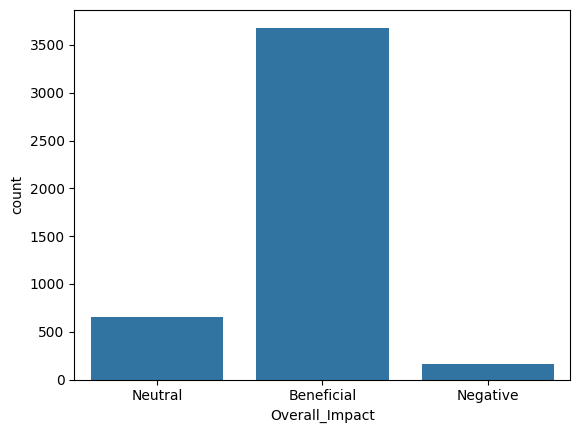

In [19]:
sns.countplot(x ='Overall_Impact', data = df)

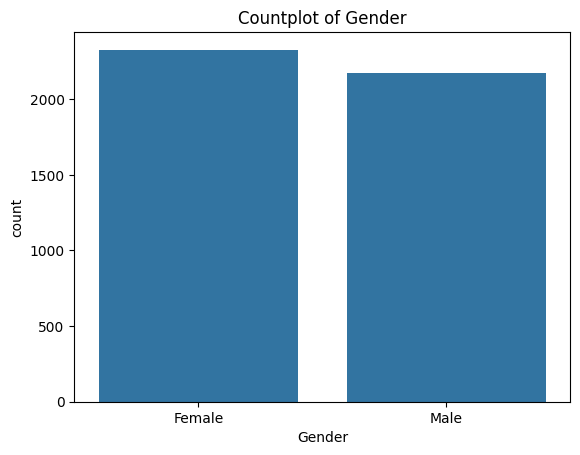

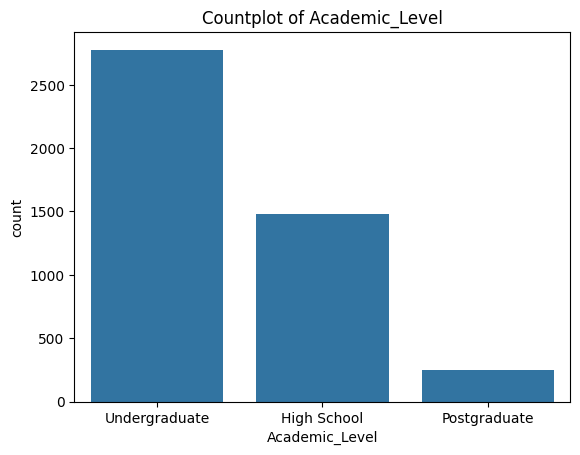

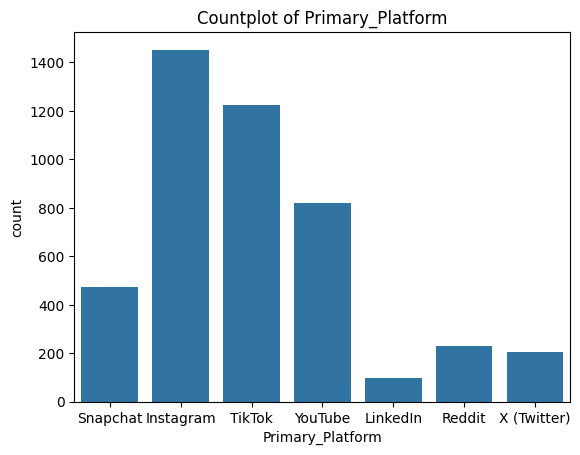

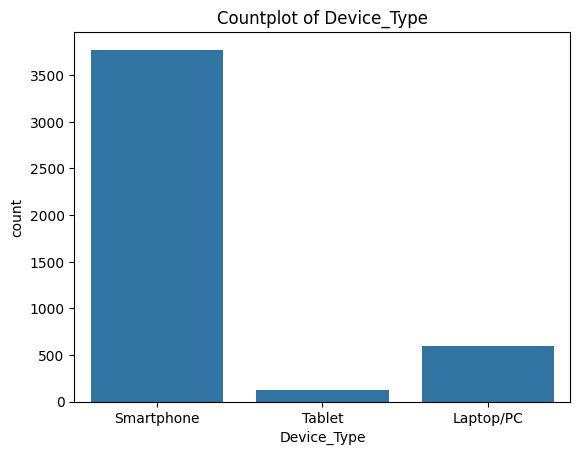

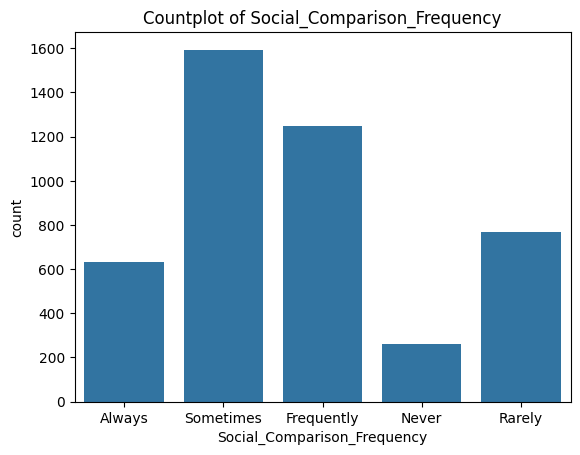

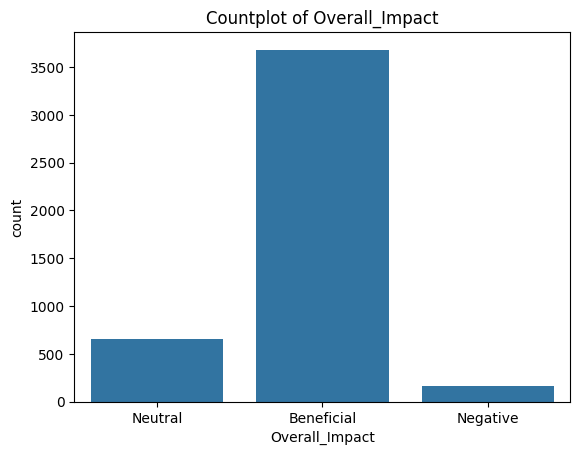

In [20]:
for column in df.columns:
    if df[column].dtype == 'object':
        sns.countplot(x = column, data = df)
        plt.title(f'Countplot of {column}')
        plt.show()

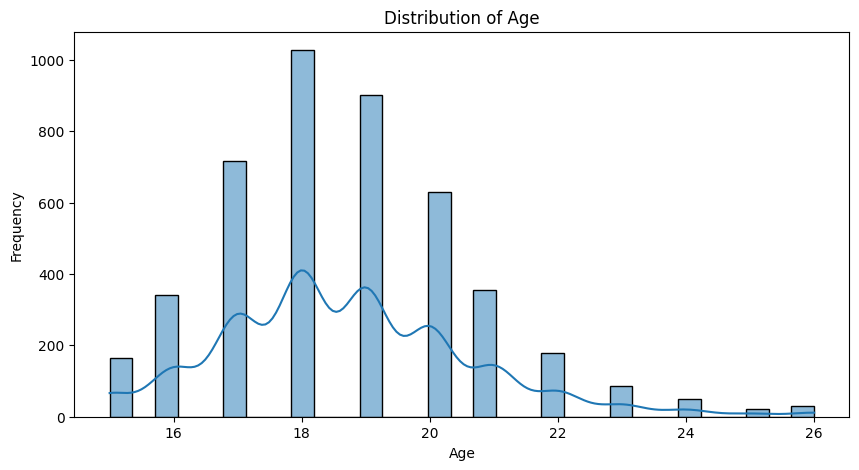

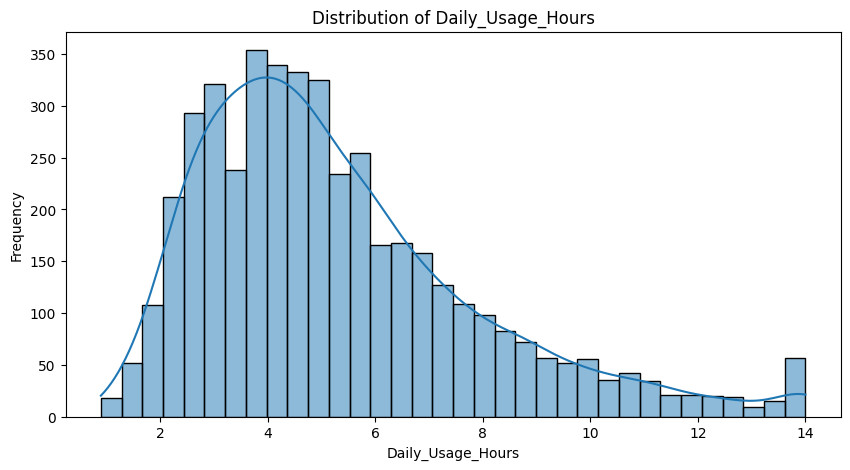

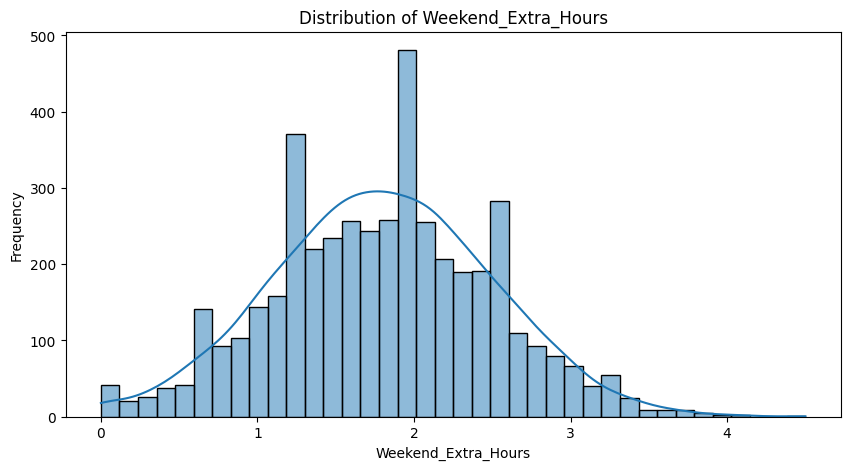

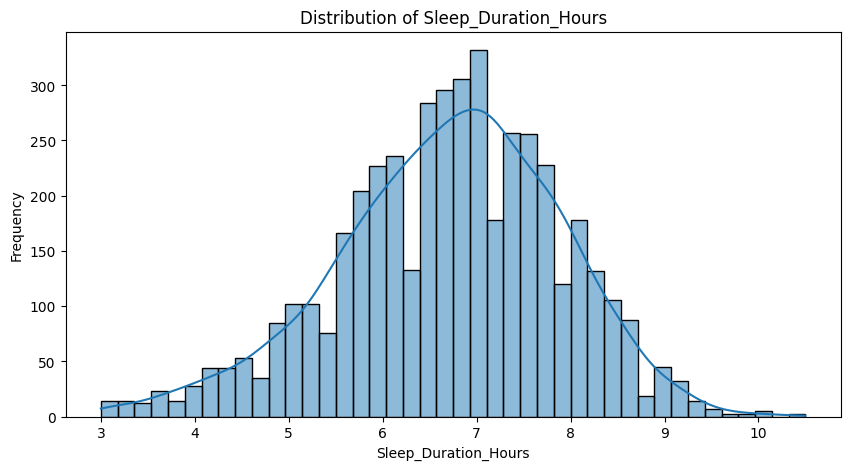

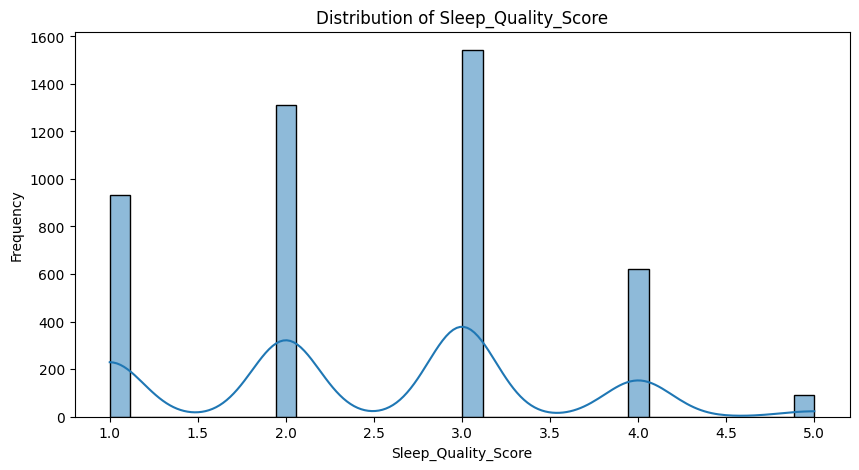

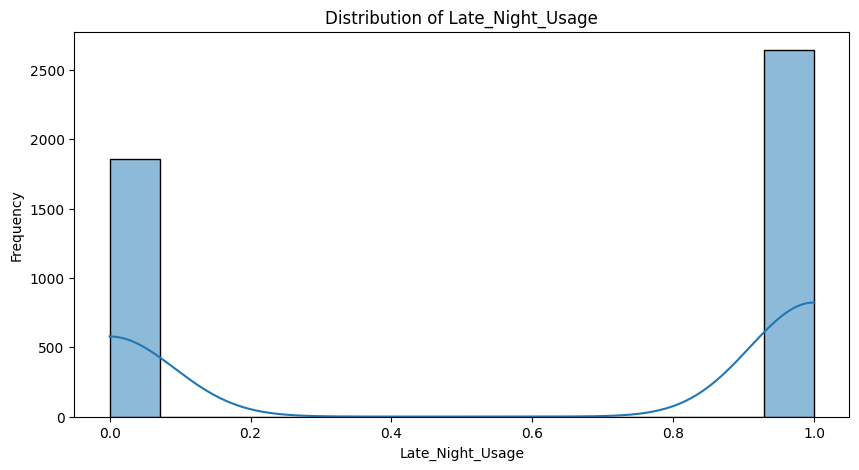

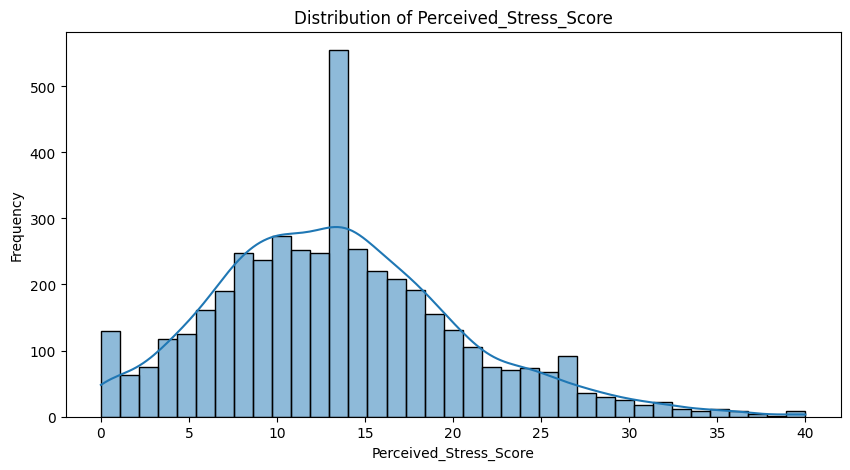

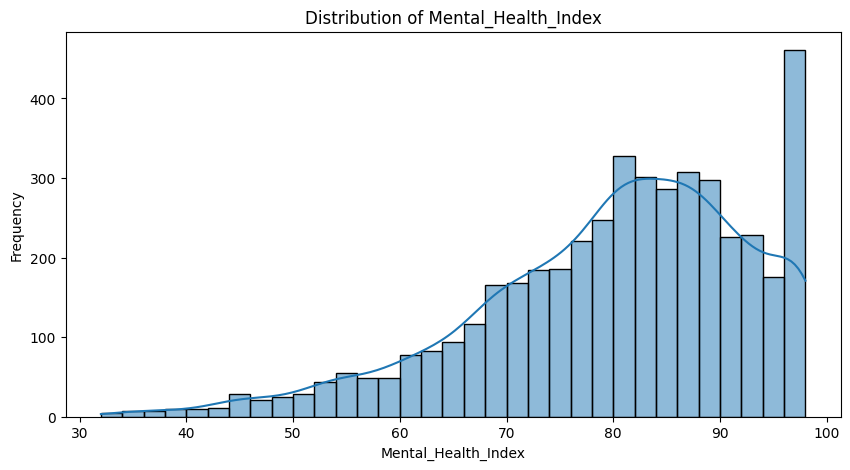

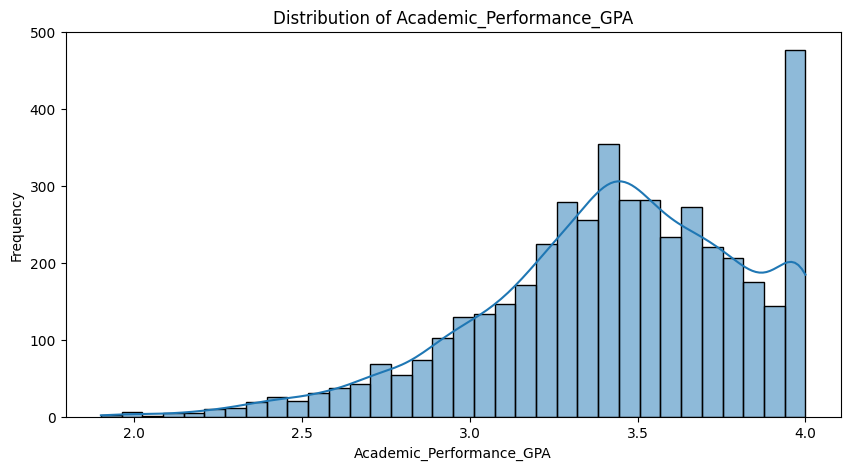

In [21]:
for column in df.columns:
    if df[column].dtype != 'object':
        plt.figure(figsize=(10, 5))
        sns.histplot(df[column], kde=True)
        plt.title(f'Distribution of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          4500 non-null   int64  
 1   Gender                       4500 non-null   object 
 2   Academic_Level               4500 non-null   object 
 3   Primary_Platform             4500 non-null   object 
 4   Daily_Usage_Hours            4500 non-null   float64
 5   Weekend_Extra_Hours          4500 non-null   float64
 6   Device_Type                  4500 non-null   object 
 7   Sleep_Duration_Hours         4500 non-null   float64
 8   Sleep_Quality_Score          4500 non-null   int64  
 9   Late_Night_Usage             4500 non-null   bool   
 10  Social_Comparison_Frequency  4500 non-null   object 
 11  Perceived_Stress_Score       4500 non-null   float64
 12  Mental_Health_Index          4500 non-null   int64  
 13  Academic_Performan

Text(0.5, 1.0, 'Countplot of Gender vs Overall Impact')

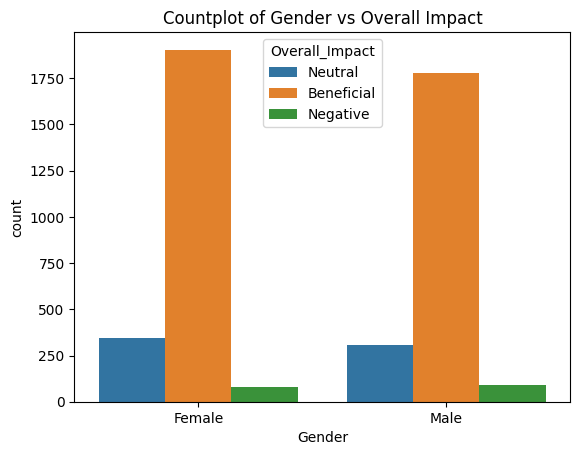

In [23]:
sns.countplot(x='Gender', data=df , hue = 'Overall_Impact')
plt.title('Countplot of Gender vs Overall Impact')

Text(0.5, 1.0, 'Countplot of Academic Level vs Overall Impact')

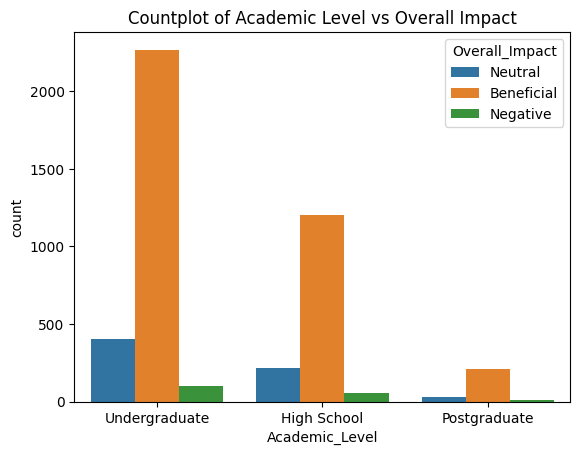

In [24]:
sns.countplot(x='Academic_Level', data=df , hue = 'Overall_Impact')
plt.title('Countplot of Academic Level vs Overall Impact')


Text(0.5, 1.0, 'Lineplot of Daily Usage Hours vs Academic Performance GPA')

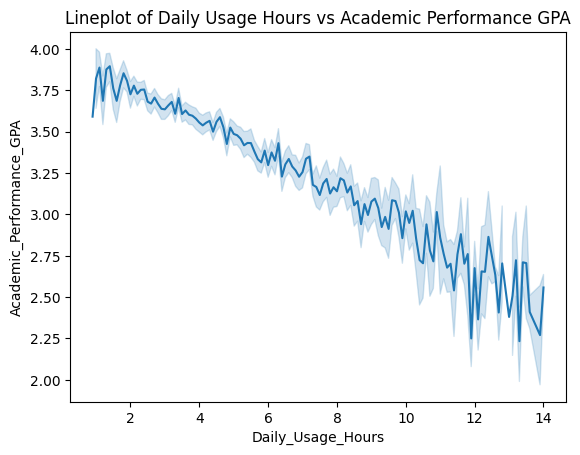

In [25]:
sns.lineplot(x='Daily_Usage_Hours', y='Academic_Performance_GPA', data=df)
plt.title('Lineplot of Daily Usage Hours vs Academic Performance GPA')

Text(0.5, 1.0, 'Lineplot of Daily Usage Hours vs Academic Performance GPA with Overall Impact')

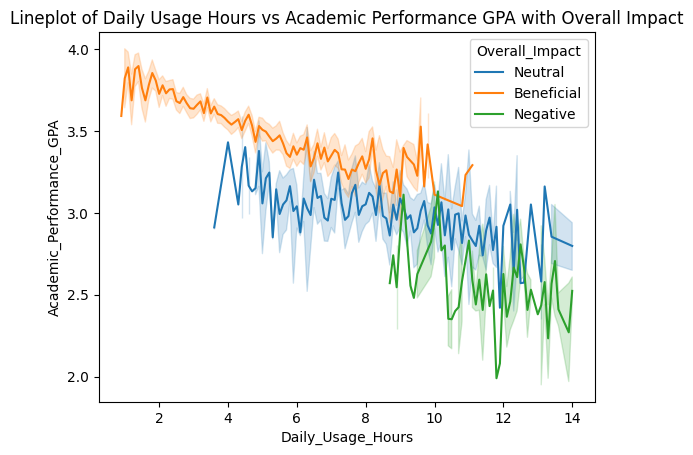

In [26]:
sns.lineplot(x='Daily_Usage_Hours', y='Academic_Performance_GPA', data=df,hue='Overall_Impact')
plt.title('Lineplot of Daily Usage Hours vs Academic Performance GPA with Overall Impact')

Text(0.5, 1.0, 'Countplot of Device Type vs Overall Impact')

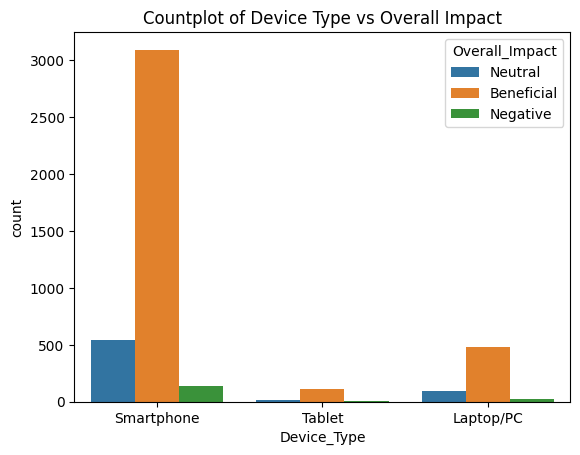

In [27]:
sns.countplot(x='Device_Type', data=df , hue = 'Overall_Impact')
plt.title('Countplot of Device Type vs Overall Impact')

Text(0.5, 1.0, 'Countplot of Late Night Usage vs Overall Impact')

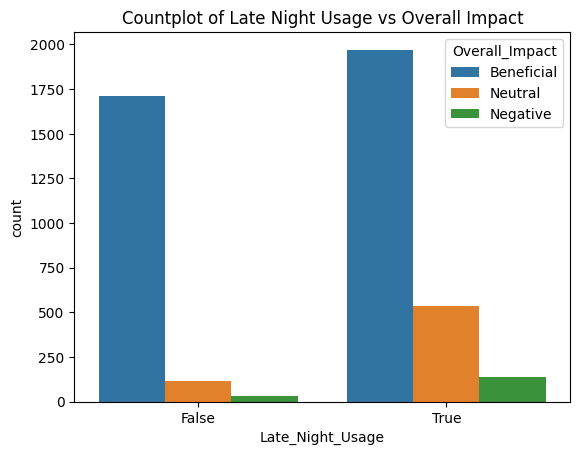

In [28]:
sns.countplot(x ='Late_Night_Usage', data = df , hue = 'Overall_Impact')
plt.title('Countplot of Late Night Usage vs Overall Impact')

Text(0.5, 1.0, 'Countplot of Social Comparison Frequency vs Overall Impact')

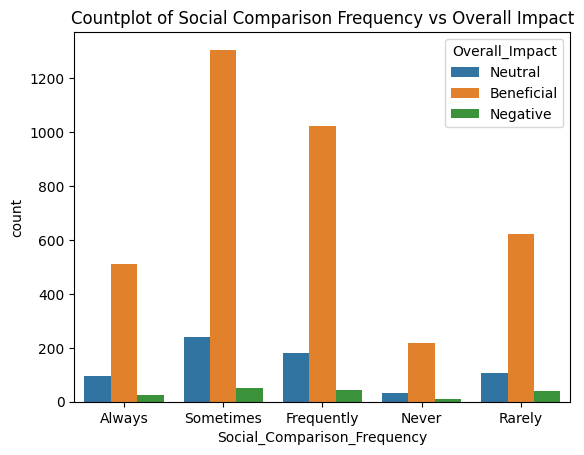

In [29]:
sns.countplot(x='Social_Comparison_Frequency', data=df,hue='Overall_Impact')
plt.title('Countplot of Social Comparison Frequency vs Overall Impact')

# **Modeling**

In [30]:
# =========================
# Preprocessing
# =========================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer

# =========================
# Train / Test & Validation
# =========================
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

# =========================
# Linear Models
# =========================
from sklearn.linear_model import (
    LogisticRegression,
    RidgeClassifier
)

# =========================
# Distance-Based Models
# =========================
from sklearn.neighbors import KNeighborsClassifier

# =========================
# Tree-Based Models
# =========================
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier
)

# =========================
# Boosting
# =========================
from xgboost import XGBClassifier

# =========================
# Pipeline
# =========================
from sklearn.pipeline import Pipeline

# =========================
# Imbalanced Data
# =========================
from imblearn.over_sampling import (
    SMOTE,
    RandomOverSampler
)

from imblearn.pipeline import Pipeline as ImbPipeline

# =========================
# Metrics & Evaluation
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# =========================
# Model Saving
# =========================
import joblib

In [31]:
df['Overall_Impact'].unique()

array(['Neutral', 'Beneficial', 'Negative'], dtype=object)

In [32]:
X = df.drop('Overall_Impact', axis=1)
y = df['Overall_Impact'].map({'Neutral': 0, 'Beneficial': 1, 'Negative': 2})

In [33]:
y.value_counts()

Overall_Impact
1    3681
0     654
2     165
Name: count, dtype: int64

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)

In [35]:
cat_col = X.select_dtypes(include=['object']).columns.tolist()
cat_col.remove('Social_Comparison_Frequency')

In [36]:
num_col = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [37]:
num_col

['Age',
 'Daily_Usage_Hours',
 'Weekend_Extra_Hours',
 'Sleep_Duration_Hours',
 'Sleep_Quality_Score',
 'Perceived_Stress_Score',
 'Mental_Health_Index',
 'Academic_Performance_GPA']

In [38]:
df['Late_Night_Usage'] = df['Late_Night_Usage'].astype(int)

In [39]:
boolean_cols = ['Late_Night_Usage']

In [40]:
ordinal_cols = ['Social_Comparison_Frequency']

In [41]:
df['Social_Comparison_Frequency'].value_counts()

Social_Comparison_Frequency
Sometimes     1594
Frequently    1248
Rarely         766
Always         632
Never          260
Name: count, dtype: int64

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', OneHotEncoder(drop='first' , handle_unknown='ignore'), cat_col),
        ('bool', 'passthrough', boolean_cols),
        ('ord', OrdinalEncoder(categories=[['Never', 'Rarely', 'Sometimes', 'Frequently', 'Always']]), ordinal_cols)
    ]
)

## logistic regression

In [43]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [44]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Gender','Academic_Level',...,'Perceived_Stress_Score', 'Mental_Health_Index','Academic_Performance_GPA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

In [45]:
y_pred_logistic = logistic_model.predict(X_test)

In [46]:
print('accuracy_score:', accuracy_score(y_test, y_pred_logistic))
print('_______________________________')
print(classification_report(y_test, y_pred_logistic))

accuracy_score: 0.9855555555555555
_______________________________
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       131
           1       0.99      0.99      0.99       736
           2       0.97      0.88      0.92        33

    accuracy                           0.99       900
   macro avg       0.97      0.95      0.96       900
weighted avg       0.99      0.99      0.99       900



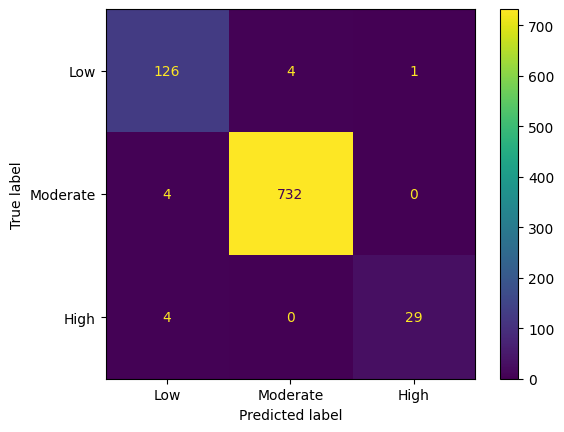

In [47]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Moderate", "High"]
)

disp.plot()
plt.show()


## KNN

In [48]:
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',KNeighborsClassifier() )
])

In [49]:
knn_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Gender','Academic_Level',...,'Perceived_Stress_Score', 'Mental_Health_Index','Academic_Performance_GPA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

In [50]:
y_pred_knn = knn_model.predict(X_test)

In [61]:
print('accuracy_score:', accuracy_score(y_test, y_pred_knn))
print('_______________________________')
print(classification_report(y_test, y_pred_knn))

accuracy_score: 0.9555555555555556
_______________________________
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       131
           1       0.97      0.99      0.98       736
           2       0.93      0.82      0.87        33

    accuracy                           0.96       900
   macro avg       0.93      0.87      0.90       900
weighted avg       0.95      0.96      0.95       900



In [62]:
grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid={
        'classifier__n_neighbors': [3, 5, 7, 9],
        'classifier__weights': ['uniform', 'distance'],
        'classifier__metric': ['euclidean', 'manhattan']
    },
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)
grid_search_knn.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\Mahmoud shaban\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__metric': ['euclidean', 'manhattan'], 'classifier__n_neighbors': [3, 5, ...], 'classifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple

In [63]:
y_pred_knn_grid = grid_search_knn.predict(X_test)

print('accuracy_score:', accuracy_score(y_test, y_pred_knn_grid))
print('_______________________________')
print(classification_report(y_test, y_pred_knn_grid))

accuracy_score: 0.9488888888888889
_______________________________
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       131
           1       0.97      0.98      0.98       736
           2       0.90      0.79      0.84        33

    accuracy                           0.95       900
   macro avg       0.90      0.86      0.88       900
weighted avg       0.95      0.95      0.95       900



# **DT**

In [59]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

In [60]:
dt_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Gender','Academic_Level',...,'Perceived_Stress_Score', 'Mental_Health_Index','Academic_Performance_GPA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

In [64]:
y_pred_dt = dt_model.predict(X_test)
print('accuracy_score:', accuracy_score(y_test, y_pred_dt))
print('_______________________________')
print(classification_report(y_test, y_pred_dt))

accuracy_score: 0.9711111111111111
_______________________________
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       131
           1       0.99      0.99      0.99       736
           2       0.85      0.88      0.87        33

    accuracy                           0.97       900
   macro avg       0.91      0.92      0.92       900
weighted avg       0.97      0.97      0.97       900



In [65]:
param_grid = {
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__max_depth': [3, 5, 7, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__criterion': ['gini', 'entropy', ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to kn

In [66]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best CV Macro F1:
0.9265642993031395


In [67]:
best_dt = grid_search.best_estimator_

y_pred_dt_grid = best_dt.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_dt_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_grid))

Test Accuracy: 0.9733333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       131
           1       0.99      0.98      0.99       736
           2       0.97      0.94      0.95        33

    accuracy                           0.97       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.97      0.97      0.97       900



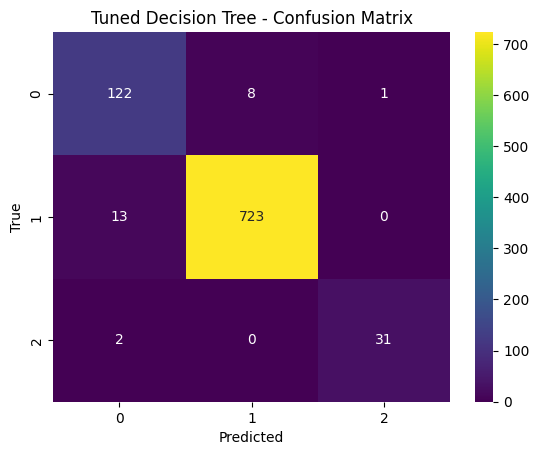

In [68]:
cm = confusion_matrix(y_test, y_pred_dt_grid)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Tuned Decision Tree - Confusion Matrix')
plt.show()

## **Random forest**

In [69]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [70]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Gender','Academic_Level',...,'Perceived_Stress_Score', 'Mental_Health_Index','Academic_Performance_GPA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

In [71]:
y_pred_rf = rf_model.predict(X_test)
print('accuracy_score:', accuracy_score(y_test, y_pred_rf))
print('_______________________________')
print(classification_report(y_test, y_pred_rf))

accuracy_score: 0.9777777777777777
_______________________________
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       131
           1       0.99      0.99      0.99       736
           2       0.97      0.88      0.92        33

    accuracy                           0.98       900
   macro avg       0.96      0.94      0.95       900
weighted avg       0.98      0.98      0.98       900



In [73]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train,y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [10, 20, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know mo

In [74]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Best CV Macro F1:
0.9265642993031395


In [75]:
best_rf = grid_search.best_estimator_

y_pred_rf_grid = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_grid))

Test Accuracy: 0.9733333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       131
           1       0.99      0.98      0.99       736
           2       0.97      0.94      0.95        33

    accuracy                           0.97       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.97      0.97      0.97       900



## **XGBoost**

In [76]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42
    ))
])

In [77]:
xgb_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','Gender','Academic_Level',...,'Perceived_Stress_Score', 'Mental_Health_Index','Academic_Performance_GPA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

In [90]:
y_pred_xgb = xgb_model.predict(X_test)


print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Test Accuracy: 0.9866666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       131
           1       1.00      0.99      0.99       736
           2       0.97      0.91      0.94        33

    accuracy                           0.99       900
   macro avg       0.97      0.96      0.96       900
weighted avg       0.99      0.99      0.99       900



In [80]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


c:\Users\Mahmoud shaban\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.01, 0.1], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about mult

In [87]:
y_pred_xgb_grid = grid_xgb.predict(X_test)
y_pred_xgb_train = grid_xgb.predict(X_train)

In [89]:
print("Best Parameters:", grid_xgb.best_params_)
print('_'*50,'\n')
print("accuracy_score:", accuracy_score(y_test, y_pred_xgb_grid))
print('___________________________\n\n')
print("accuracy_score_train:", accuracy_score(y_train, y_pred_xgb_train))
print('_'*50,'\n')
print(classification_report(y_test, y_pred_xgb_grid))

Best Parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
__________________________________________________ 

accuracy_score: 0.9455555555555556
___________________________


accuracy_score_train: 0.9511111111111111
__________________________________________________ 

              precision    recall  f1-score   support

           0       0.90      0.73      0.81       131
           1       0.95      1.00      0.97       736
           2       1.00      0.58      0.73        33

    accuracy                           0.95       900
   macro avg       0.95      0.77      0.84       900
weighted avg       0.94      0.95      0.94       900



## **VotingClassifier**

In [85]:

logistic = LogisticRegression()

xgb = XGBClassifier()

voting_model = VotingClassifier(
    estimators=[
        ('logistic', logistic),
        ('xgb', xgb)
    ],
    voting='soft'
)

voting_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('voting', voting_model)
])

voting_pipeline.fit(X_train, y_train)

y_pred_voting = voting_pipeline.predict(X_test)

In [86]:
print("Accuracy:", accuracy_score(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))

Accuracy: 0.9833333333333333
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       131
           1       1.00      0.99      0.99       736
           2       0.94      0.91      0.92        33

    accuracy                           0.98       900
   macro avg       0.95      0.95      0.95       900
weighted avg       0.98      0.98      0.98       900



In [91]:

models_predictions = {
    'Logistic Regression': y_pred_logistic,
    'KNN': y_pred_knn,
    'KNN GridSearch': y_pred_knn_grid,
    'Decision Tree': y_pred_dt,
    'Decision Tree GridSearch': y_pred_dt_grid,
    'Random Forest': y_pred_rf,
    'Random Forest GridSearch': y_pred_rf_grid,
    'XGBoost': y_pred_xgb,
    'XGBoost GridSearch': y_pred_xgb_grid,
    'Voting Classifier': y_pred_voting
}

for model_name, y_pred in models_predictions.items():
    
    print("=" * 70)
    print(f" {model_name}")
    print("=" * 70)
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['Neutral', 'Beneficial', 'Negative'],
            digits=4
        )
    )

 Logistic Regression
              precision    recall  f1-score   support

     Neutral     0.9403    0.9618    0.9509       131
  Beneficial     0.9946    0.9946    0.9946       736
    Negative     0.9667    0.8788    0.9206        33

    accuracy                         0.9856       900
   macro avg     0.9672    0.9451    0.9554       900
weighted avg     0.9856    0.9856    0.9855       900

 KNN
              precision    recall  f1-score   support

     Neutral     0.8760    0.8092    0.8413       131
  Beneficial     0.9693    0.9878    0.9785       736
    Negative     0.9310    0.8182    0.8710        33

    accuracy                         0.9556       900
   macro avg     0.9255    0.8717    0.8969       900
weighted avg     0.9543    0.9556    0.9546       900

 KNN GridSearch
              precision    recall  f1-score   support

     Neutral     0.8455    0.7939    0.8189       131
  Beneficial     0.9679    0.9837    0.9757       736
    Negative     0.8966    0.7879

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

models_predictions = {
    'Logistic Regression': y_pred_logistic,
    'KNN': y_pred_knn,
    'KNN GridSearch': y_pred_knn_grid,
    'Decision Tree': y_pred_dt,
    'Decision Tree GridSearch': y_pred_dt_grid,
    'Random Forest': y_pred_rf,
    'Random Forest GridSearch': y_pred_rf_grid,
    'XGBoost': y_pred_xgb,
    'XGBoost GridSearch': y_pred_xgb_grid,
    'Voting Classifier': y_pred_voting
}

results = []

for model_name, y_pred in models_predictions.items():

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro')
    })

comparison = pd.DataFrame(results)

comparison[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
] = comparison[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
].round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9856,0.9672,0.9451,0.9554
1,KNN,0.9556,0.9255,0.8717,0.8969
2,KNN GridSearch,0.9489,0.9033,0.8552,0.8778
3,Decision Tree,0.9711,0.9143,0.9224,0.9183
4,Decision Tree GridSearch,0.9733,0.9494,0.9510,0.9500
5,Random Forest,0.9778,0.9561,0.9356,0.9451
6,Random Forest GridSearch,0.9733,0.9494,0.9510,0.9500
7,XGBoost,0.9867,0.9664,0.9593,0.9624
8,XGBoost GridSearch,0.9456,0.9494,0.7695,0.8374
9,Voting Classifier,0.9833,0.9533,0.9538,0.9534


# **Import model**

In [95]:
joblib.dump(xgb_model,'Social_media_predector.pkl')

['Social_media_predector.pkl']

In [97]:
model = joblib.load('Social_media_predector.pkl')

In [100]:
new_data = pd.DataFrame({
    'Age': [20],
    'Gender': ['Male'],
    'Academic_Level': ['Undergraduate'],
    'Primary_Platform': ['Instagram'],
    'Daily_Usage_Hours': [6.5],
    'Weekend_Extra_Hours': [2.0],
    'Device_Type': ['Smartphone'],
    'Sleep_Duration_Hours': [6.0],
    'Sleep_Quality_Score': [5],
    'Late_Night_Usage': [1],
    'Social_Comparison_Frequency': ['Frequently'],
    'Perceived_Stress_Score': [8],
    'Mental_Health_Index': [45],
    'Academic_Performance_GPA': [2.7]
})

In [101]:
prediction = model.predict(new_data)

In [102]:
probability = model.predict_proba(new_data)


In [103]:
probability

array([[0.92777723, 0.06876849, 0.00345431]], dtype=float32)

In [105]:
label_map = {
    0: 'Neutral',
    1: 'Beneficial',
    2: 'Negative'
}

print("Prediction:", label_map[prediction[0]])

Prediction: Neutral
